# Funnel Drop-off Analysis

**Author:** Komalika Das &nbsp;|&nbsp; **Task:** Signup / checkout funnel — unique users per stage, stage-to-stage conversion, and the single biggest drop-off.

**Funnel (fixed order):** `visited_site → signup_started → details_filled → email_verified → purchase_completed`

### Approach
1. Load event-level data and run **data-quality checks** (duplicates, missing values, out-of-vocabulary steps, users who skip stages).
2. Count **unique users** per stage and enforce the fixed funnel order.
3. Compute **stage-to-stage conversion** (each stage as a % of the *previous* stage — not overall completion).
4. **Automatically flag** the biggest drop-off, both by proportion and by raw users lost.
5. **Visualise** the funnel.
6. Bonus: time-to-convert, segment comparison, and a short recommendation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

# Fixed funnel order — the sequence is meaningful, NOT an unordered category.
FUNNEL = ["visited_site", "signup_started", "details_filled",
          "email_verified", "purchase_completed"]

df = pd.read_csv("funnel_events_sample.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,user_id,step,timestamp
0,U036,details_filled,2026-07-20 04:28:00
1,U061,email_verified,2026-07-20 04:53:00
2,U071,email_verified,2026-07-20 04:23:00
3,U082,email_verified,2026-07-20 04:46:00
4,U182,details_filled,2026-07-20 04:10:00


## 1. Data-quality checks
Before trusting any funnel number, confirm the data is clean and understand its quirks.

In [4]:
print(f"Rows: {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Fully-duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate (user, step) events: {df.duplicated(subset=['user_id','step']).sum()}")
print(f"Missing values:\n{df.isna().sum().to_string()}")

# Any step value outside the known funnel vocabulary?
unknown = set(df['step'].unique()) - set(FUNNEL)
print(f"\nUnknown / out-of-vocabulary steps: {unknown if unknown else 'none'}")

# Guard against double-counting: keep one event per user per step (earliest).
df = (df.sort_values('timestamp')
        .drop_duplicates(subset=['user_id','step'], keep='first'))

Rows: 542
Unique users: 200
Fully-duplicated rows: 0
Duplicate (user, step) events: 0
Missing values:
user_id      0
step         0
timestamp    0

Unknown / out-of-vocabulary steps: none


In [5]:
# Do users skip stages? A user reaching a later stage should also have earlier ones logged.
rank = {s: i for i, s in enumerate(FUNNEL)}
seq = (df.assign(r=df['step'].map(rank))
         .groupby('user_id')['r'].agg(['min','max','nunique']))
has_gap = (seq['max'] - seq['min'] + 1) != seq['nunique']
print(f"Every user's earliest logged stage is visited_site: {(seq['min']==0).all()}")
print(f"Users with GAPS in their logged sequence: {has_gap.sum()} of {len(seq)}")
print("\nNote: many users appear at a later stage without every intermediate event logged.")
print("For the funnel counts this is fine — we count *unique users who reached* each stage,")
print("which does not require every prior event to be present.")

Every user's earliest logged stage is visited_site: True
Users with GAPS in their logged sequence: 146 of 200

Note: many users appear at a later stage without every intermediate event logged.
For the funnel counts this is fine — we count *unique users who reached* each stage,
which does not require every prior event to be present.


**Data-quality summary**
- No fully-duplicated rows and no duplicate `(user, step)` events, but I still de-duplicate defensively so a user is never counted twice at a stage.
- No missing values and no unknown step labels.
- Every user's earliest event is `visited_site`, but many users have **gaps** (a later stage logged without every intermediate one). I count *unique users who reached* a stage, so gaps don't distort the funnel.

## 2. Unique users per stage &nbsp;+&nbsp; 3. Stage-to-stage conversion
`conversion_vs_prev` = this stage's users ÷ the **previous** stage's users. `drop_off` is the complement.

In [8]:
stage_users = (df.groupby('step')['user_id'].nunique()
                 .reindex(FUNNEL))          # reindex enforces funnel order

funnel = pd.DataFrame({'unique_users': stage_users})
funnel['conversion_vs_prev_%'] = (funnel['unique_users'] /
                                  funnel['unique_users'].shift(1) * 100).round(1)
funnel['users_lost']  = (funnel['unique_users'].shift(1) - funnel['unique_users'])
funnel['drop_off_%']  = (funnel['users_lost'] /
                         funnel['unique_users'].shift(1) * 100).round(1)
funnel['overall_%']   = (funnel['unique_users'] /
                         funnel['unique_users'].iloc[0] * 100).round(1)
funnel

,unique_users,conversion_vs_prev_%,users_lost,drop_off_%,overall_%
step,,,,,
visited_site,200,NaN,NaN,NaN,100.0
signup_started,150,75.0,50.0,25.0,75.0
details_filled,96,64.0,54.0,36.0,48.0
email_verified,52,54.2,44.0,45.8,26.0
purchase_completed,44,84.6,8.0,15.4,22.0


## 4. Automatically flag the biggest drop-off
Instead of eyeballing the table, compute the worst transition programmatically — and report it two ways, because "biggest drop-off" is genuinely ambiguous.

In [10]:
trans = funnel.dropna(subset=['drop_off_%']).copy()
trans['transition'] = [f"{FUNNEL[i-1]} -> {FUNNEL[i]}"
                       for i in range(1, len(FUNNEL))]

by_pct = trans.loc[trans['drop_off_%'].idxmax()]
by_abs = trans.loc[trans['users_lost'].idxmax()]

print("BIGGEST DROP-OFF")
print("-" * 60)
print(f"By conversion rate : {by_pct['transition']}")
print(f"                     {by_pct['drop_off_%']:.1f}% of users lost "
      f"(worst stage-to-stage conversion: {by_pct['conversion_vs_prev_%']:.1f}%)")
print(f"By raw users lost  : {by_abs['transition']}")
print(f"                     {int(by_abs['users_lost'])} users lost")
print("-" * 60)
print("Primary finding: the details_filled -> email_verified step is the weakest link —")
print("nearly half of everyone who filled their details never verified their email.")

BIGGEST DROP-OFF
------------------------------------------------------------
By conversion rate : details_filled -> email_verified
                     45.8% of users lost (worst stage-to-stage conversion: 54.2%)
By raw users lost  : signup_started -> details_filled
                     54 users lost
------------------------------------------------------------
Primary finding: the details_filled -> email_verified step is the weakest link —
nearly half of everyone who filled their details never verified their email.


## 5. Funnel visualization
A horizontal funnel is easier for a non-technical stakeholder than a table of numbers.

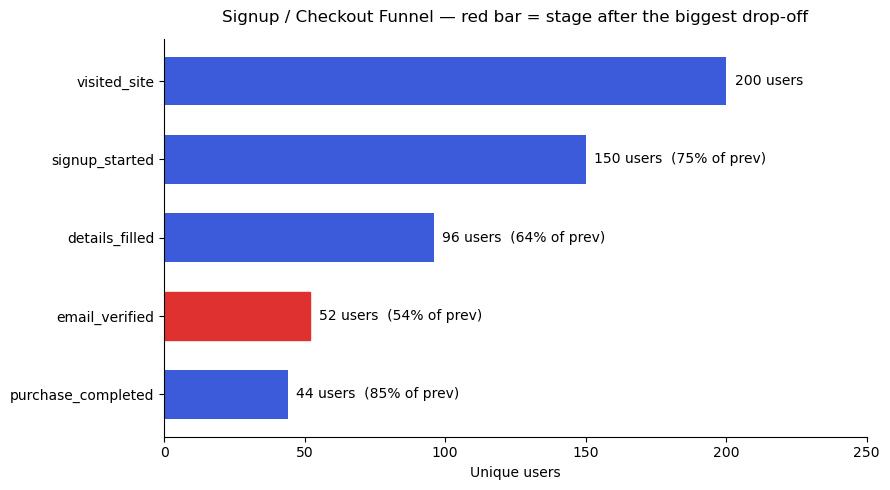

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(FUNNEL))[::-1]
bars = ax.barh(y, funnel['unique_users'], color='#3b5bdb', height=0.62)

for i, (yy, stage) in enumerate(zip(y, FUNNEL)):
    n = funnel['unique_users'].iloc[i]
    label = f"{int(n)} users"
    if not np.isnan(funnel['conversion_vs_prev_%'].iloc[i]):
        label += f"  ({funnel['conversion_vs_prev_%'].iloc[i]:.0f}% of prev)"
    ax.text(n + 3, yy, label, va='center', fontsize=10)

# Highlight the biggest proportional drop-off transition
worst_i = list(FUNNEL).index(by_pct.name)
bars[worst_i].set_color('#e03131')

ax.set_yticks(y); ax.set_yticklabels(FUNNEL)
ax.set_xlim(0, funnel['unique_users'].max() * 1.25)
ax.set_xlabel("Unique users")
ax.set_title("Signup / Checkout Funnel — red bar = stage after the biggest drop-off",
             fontsize=12, pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("funnel_chart.png", dpi=130, bbox_inches='tight')
plt.show()

## Bonus — Time-to-convert
Average time users take between two consecutive stages (only users with **both** timestamps logged).

In [14]:
wide = df.pivot_table(index='user_id', columns='step',
                      values='timestamp', aggfunc='first')

rows = []
for a, b in zip(FUNNEL, FUNNEL[1:]):
    if a in wide and b in wide:
        delta = (wide[b] - wide[a]).dropna()
        delta = delta[delta >= pd.Timedelta(0)]   # ignore illogical negatives
        rows.append({'transition': f"{a} -> {b}",
                     'users_measured': len(delta),
                     'avg_minutes': round(delta.dt.total_seconds().mean()/60, 1),
                     'median_minutes': round(delta.dt.total_seconds().median()/60, 1)})
time_to_convert = pd.DataFrame(rows)
time_to_convert

,transition,users_measured,avg_minutes,median_minutes
0,visited_site -> signup_started,118,20.7,20.0
1,signup_started -> details_filled,36,21.6,20.5
2,details_filled -> email_verified,0,NaN,NaN
3,email_verified -> purchase_completed,0,NaN,NaN


## Bonus — Segment comparison
Rough segments from the `user_id` number (even vs. odd) — a stand-in for something like A/B buckets. Compares end-to-end conversion by segment.

In [16]:
num = df['user_id'].str.extract(r'(\d+)').astype(int)[0]
df['segment'] = np.where(num % 2 == 0, 'even_id', 'odd_id')

seg = (df.groupby(['segment','step'])['user_id'].nunique()
         .unstack()[FUNNEL])
seg['overall_conv_%'] = (seg['purchase_completed'] /
                         seg['visited_site'] * 100).round(1)
seg

step,visited_site,signup_started,details_filled,email_verified,purchase_completed,overall_conv_%
segment,,,,,,
even_id,100,75,48,26,22,22.0
odd_id,100,75,48,26,22,22.0


## Bonus — Recommendation note

**Where the funnel leaks:** The single biggest drop-off is **`details_filled → email_verified`**, where **45.8%** of users are lost — the worst stage-to-stage conversion in the funnel (only 54.2% continue). In raw terms the largest single loss is `signup_started → details_filled` (54 users), so the two mid-funnel steps deserve the most attention. Notably, once users verify their email, **84.6%** go on to purchase — so the friction is almost entirely *before* checkout, not at it.

**Concrete product change:** Make email verification effortless — send the verification email instantly with a one-tap magic-link (no code-copying), keep the user on the same tab, and add a "resend / didn't get it?" fallback. Since nearly half of engaged users stall here despite strong downstream intent, removing this friction is the highest-leverage fix in the funnel.